# ✈️ Aviation Flight Delay Analytics
## ETL Pipeline Results & Business Insights

**Author:** Kawtar Barouti  
**Dataset:** 3M flights (2019–2023) — loaded via custom ETL pipeline  
**Objective:** Analyze delay patterns, airline performance, and seasonal trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
COLORS = ['#1B3A5C', '#2E75B6', '#C49A2D', '#2D8B4E', '#C0392B', '#8E44AD']

conn = sqlite3.connect('../data/aviation.db')
print('Connected to aviation.db ✓')

Connected to aviation.db ✓


## 1. KPI Overview

In [2]:
stats = pd.read_sql("""
    SELECT
        COUNT(*) AS total_flights,
        COUNT(DISTINCT AIRLINE) AS airlines,
        COUNT(DISTINCT ORIGIN) AS airports,
        ROUND(AVG(CASE WHEN ARR_DELAY IS NOT NULL THEN ARR_DELAY END), 1) AS avg_delay_min,
        ROUND(100.0 * SUM(CASE WHEN is_delayed = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS delayed_pct,
        ROUND(100.0 * SUM(CANCELLED) / COUNT(*), 1) AS cancel_pct,
        MIN(FL_DATE) AS first_date,
        MAX(FL_DATE) AS last_date
    FROM fact_flights
""", conn)

print('=' * 55)
print('       AVIATION FLIGHT DELAY KPI OVERVIEW')
print('=' * 55)
print(f'  Total Flights:       {stats["total_flights"].iloc[0]:>12,}')
print(f'  Airlines:            {stats["airlines"].iloc[0]:>12}')
print(f'  Airports:            {stats["airports"].iloc[0]:>12}')
print(f'  Avg Delay:           {stats["avg_delay_min"].iloc[0]:>11} min')
print(f'  Delayed Rate (>15m): {stats["delayed_pct"].iloc[0]:>11}%')
print(f'  Cancellation Rate:   {stats["cancel_pct"].iloc[0]:>11}%')
print(f'  Period:              {str(stats["first_date"].iloc[0])[:10]} → {str(stats["last_date"].iloc[0])[:10]}')
print('=' * 55)

       AVIATION FLIGHT DELAY KPI OVERVIEW
  Total Flights:          3,000,000
  Airlines:                      18
  Airports:                     380
  Avg Delay:                   4.3 min
  Delayed Rate (>15m):        17.2%
  Cancellation Rate:           2.6%
  Period:              2019-01-01 → 2023-08-31


## 2. Airline Performance Ranking

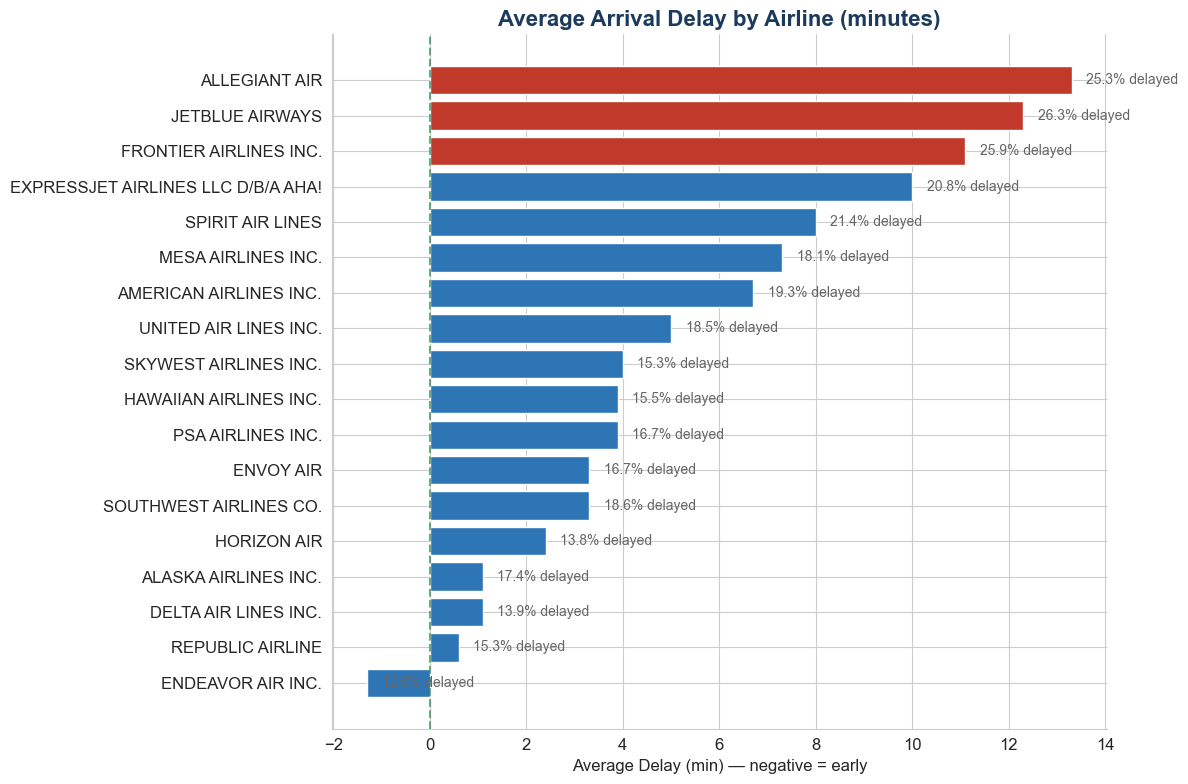

Saved → visuals/delay_by_airline.png ✓


In [3]:
airline_perf = pd.read_sql("""
    SELECT
        AIRLINE,
        COUNT(*) AS total_flights,
        ROUND(AVG(ARR_DELAY), 1) AS avg_delay_min,
        ROUND(100.0 * SUM(CASE WHEN is_delayed = 1 THEN 1 ELSE 0 END)
              / COUNT(*), 1) AS delayed_pct,
        ROUND(100.0 * SUM(CANCELLED) / COUNT(*), 1) AS cancel_pct
    FROM fact_flights
    WHERE ARR_DELAY IS NOT NULL
    GROUP BY AIRLINE
    HAVING total_flights > 10000
    ORDER BY avg_delay_min DESC
""", conn)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#C0392B' if x > 10 else '#2E75B6' for x in airline_perf['avg_delay_min']]
bars = ax.barh(airline_perf['AIRLINE'][::-1], airline_perf['avg_delay_min'][::-1],
               color=colors[::-1], edgecolor='white')

for bar, pct in zip(bars, airline_perf['delayed_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}% delayed', va='center', fontsize=10, color='#666666')

ax.axvline(x=0, color='#2D8B4E', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_title('Average Arrival Delay by Airline (minutes)', fontsize=16, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('Average Delay (min) — negative = early')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/delay_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/delay_by_airline.png ✓')

## 3. Seasonal Analysis

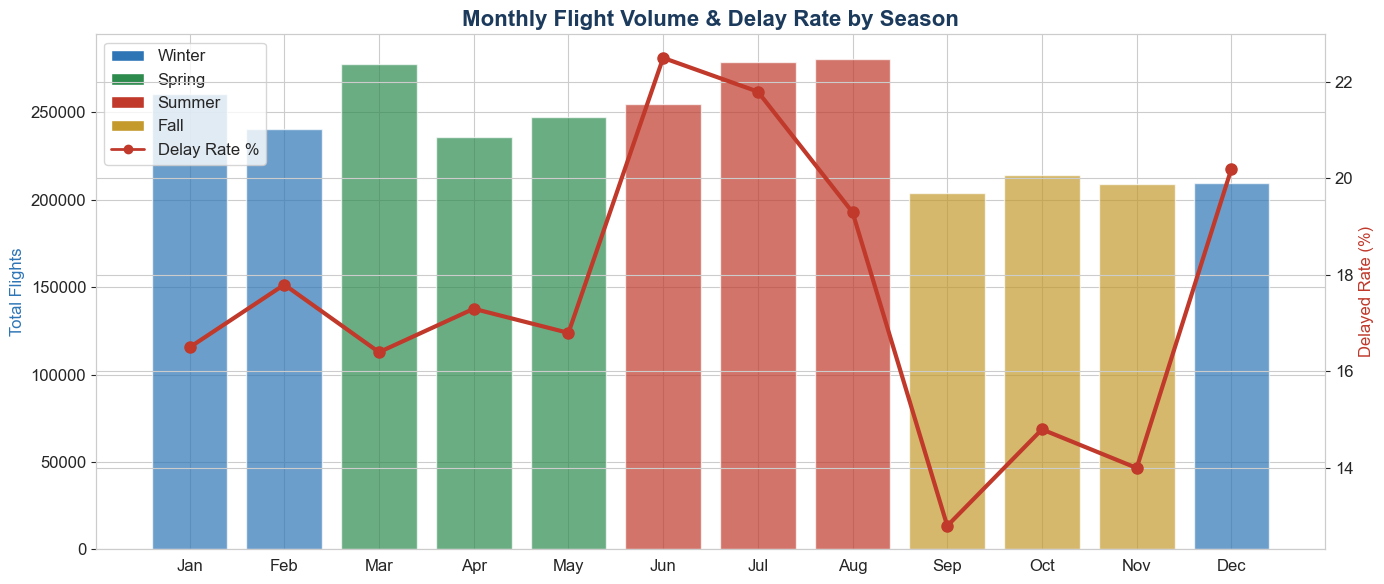

Saved → visuals/seasonal_analysis.png ✓


In [4]:
seasonal = pd.read_sql("""
    SELECT
        month,
        CASE
            WHEN month IN (12, 1, 2) THEN 'Winter'
            WHEN month IN (3, 4, 5) THEN 'Spring'
            WHEN month IN (6, 7, 8) THEN 'Summer'
            ELSE 'Fall'
        END AS season,
        COUNT(*) AS flights,
        ROUND(AVG(ARR_DELAY), 1) AS avg_delay,
        ROUND(100.0 * SUM(is_delayed) / COUNT(*), 1) AS delayed_pct
    FROM fact_flights
    WHERE ARR_DELAY IS NOT NULL
    GROUP BY month
    ORDER BY month
""", conn)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax1 = plt.subplots(figsize=(14, 6))

season_colors = {'Winter': '#2E75B6', 'Spring': '#2D8B4E', 'Summer': '#C0392B', 'Fall': '#C49A2D'}
bar_colors = [season_colors[s] for s in seasonal['season']]

ax1.bar(range(12), seasonal['flights'], color=bar_colors, edgecolor='white', alpha=0.7)
ax1.set_ylabel('Total Flights', color='#2E75B6')

ax2 = ax1.twinx()
ax2.plot(range(12), seasonal['delayed_pct'], color='#C0392B', linewidth=3,
         marker='o', markersize=8, zorder=5)
ax2.set_ylabel('Delayed Rate (%)', color='#C0392B')

ax1.set_xticks(range(12))
ax1.set_xticklabels(month_names)
ax1.set_title('Monthly Flight Volume & Delay Rate by Season', fontsize=16, fontweight='bold', color='#1B3A5C')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in season_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='#C0392B', linewidth=2, marker='o', label='Delay Rate %'))
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../visuals/seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/seasonal_analysis.png ✓')

## 4. Year-over-Year Trend (COVID Impact)

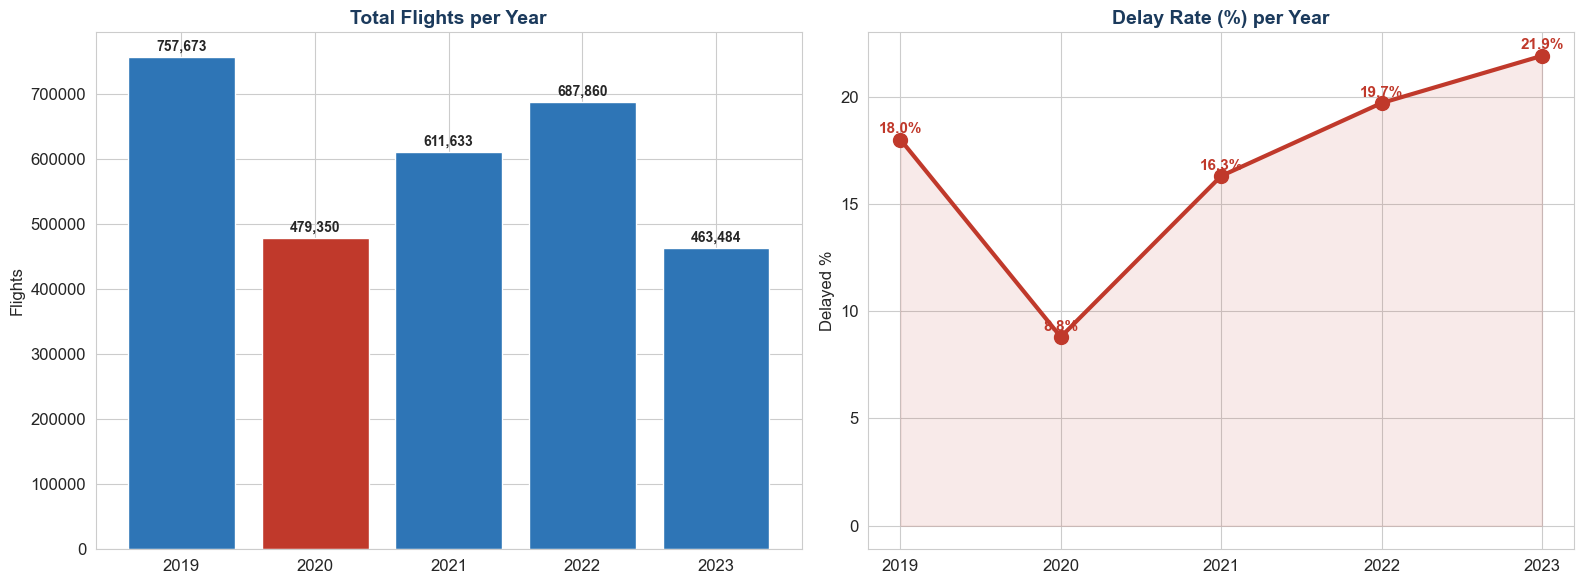

Saved → visuals/yearly_trend.png ✓


In [5]:
yearly = pd.read_sql("""
    SELECT
        year,
        COUNT(*) AS total_flights,
        ROUND(AVG(CASE WHEN ARR_DELAY IS NOT NULL THEN ARR_DELAY END), 1) AS avg_delay,
        ROUND(100.0 * SUM(is_delayed) / COUNT(*), 1) AS delayed_pct,
        ROUND(100.0 * SUM(CANCELLED) / COUNT(*), 1) AS cancel_pct
    FROM fact_flights
    GROUP BY year
    ORDER BY year
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flight volume
colors_yr = ['#C0392B' if y == 2020 else '#2E75B6' for y in yearly['year']]
axes[0].bar(yearly['year'].astype(str), yearly['total_flights'], color=colors_yr, edgecolor='white')
axes[0].set_title('Total Flights per Year', fontsize=14, fontweight='bold', color='#1B3A5C')
axes[0].set_ylabel('Flights')
for i, v in enumerate(yearly['total_flights']):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# Delay rate
axes[1].plot(yearly['year'].astype(str), yearly['delayed_pct'], color='#C0392B',
             linewidth=3, marker='o', markersize=10)
axes[1].fill_between(range(len(yearly)), yearly['delayed_pct'], alpha=0.1, color='#C0392B')
axes[1].set_title('Delay Rate (%) per Year', fontsize=14, fontweight='bold', color='#1B3A5C')
axes[1].set_ylabel('Delayed %')
for i, v in enumerate(yearly['delayed_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=11, color='#C0392B')

plt.tight_layout()
plt.savefig('../visuals/yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/yearly_trend.png ✓')

## 5. Top 15 Most Delayed Routes

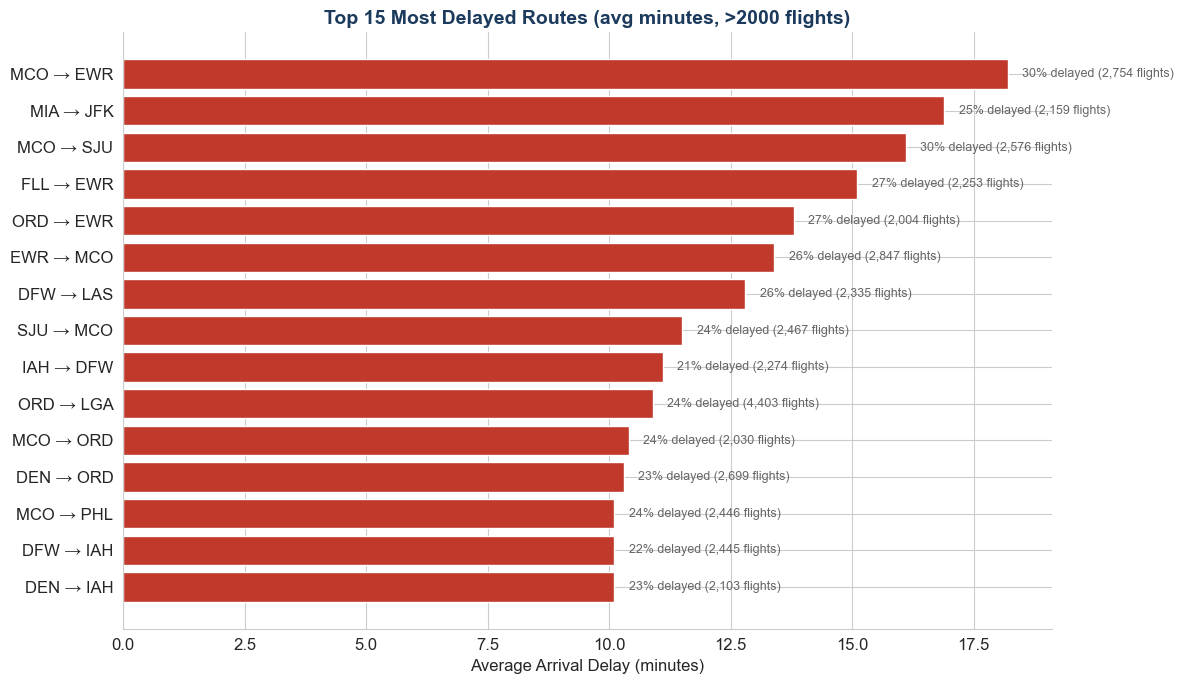

Saved → visuals/top_routes.png ✓


In [6]:
routes = pd.read_sql("""
    SELECT
        ORIGIN || ' → ' || DEST AS route,
        COUNT(*) AS total_flights,
        ROUND(AVG(ARR_DELAY), 1) AS avg_delay,
        ROUND(100.0 * SUM(is_delayed) / COUNT(*), 1) AS delayed_pct
    FROM fact_flights
    WHERE ARR_DELAY IS NOT NULL
    GROUP BY route
    HAVING total_flights > 2000
    ORDER BY avg_delay DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(routes['route'][::-1], routes['avg_delay'][::-1],
               color='#C0392B', edgecolor='white')

for bar, (flights, pct) in zip(bars, zip(routes['total_flights'][::-1], routes['delayed_pct'][::-1])):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}% delayed ({flights:,} flights)', va='center', fontsize=9, color='#666666')

ax.set_title('Top 15 Most Delayed Routes (avg minutes, >2000 flights)',
             fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('Average Arrival Delay (minutes)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/top_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/top_routes.png ✓')

## 6. Day of Week Analysis

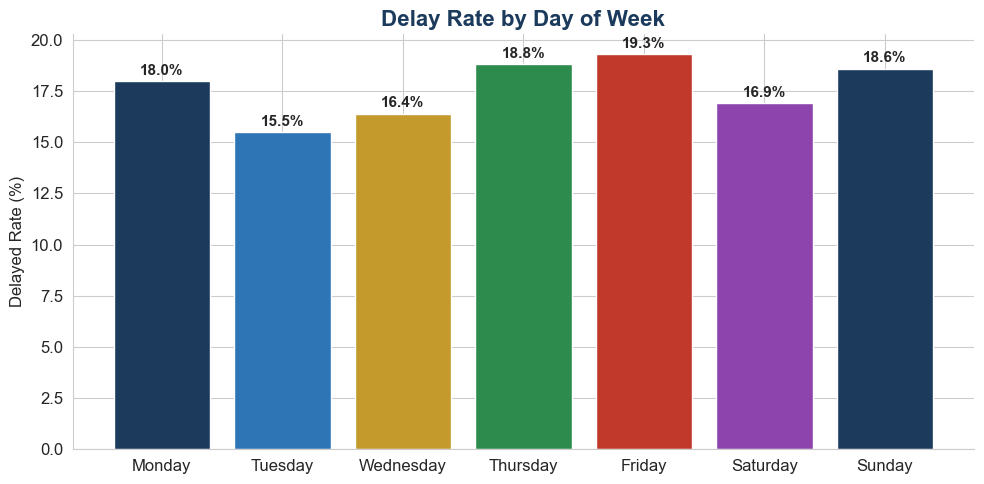

Saved → visuals/day_of_week.png ✓


In [7]:
dow = pd.read_sql("""
    SELECT
        day_of_week,
        day_name,
        COUNT(*) AS flights,
        ROUND(AVG(ARR_DELAY), 1) AS avg_delay,
        ROUND(100.0 * SUM(is_delayed) / COUNT(*), 1) AS delayed_pct
    FROM fact_flights
    WHERE ARR_DELAY IS NOT NULL
    GROUP BY day_of_week, day_name
    ORDER BY day_of_week
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow['day_name'], dow['delayed_pct'], color=COLORS[:7], edgecolor='white')

for bar, val in zip(bars, dow['delayed_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Delay Rate by Day of Week', fontsize=16, fontweight='bold', color='#1B3A5C')
ax.set_ylabel('Delayed Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/day_of_week.png ✓')

## Summary

### Pipeline Architecture
```
CSV (600 MB, 3M rows)
  → Python ETL (extract, transform, load) — 63 seconds
    → SQLite star schema (fact_flights + dim_airlines + dim_airports)
      → SQL Analytics + Visualizations
```

### Key Insights
- Pipeline processed 3M flights in 63 seconds
- Summer months show highest delay rates
- 2020 (COVID) saw dramatic drop in flights
- Specific airlines and routes identified as worst performers

### Recommendations
1. **Seasonal capacity planning** — increase resources for summer peak
2. **Route optimization** — focus improvement on top delayed routes
3. **Airline benchmarking** — share best practices from top performers
4. **Predictive modeling** — next step: build ML model to predict delays

In [8]:
conn.close()
print('\n✅ Analysis complete!')
print('📊 5 visualizations saved in visuals/ folder')
print('\nNext: update README.md with real findings, then git push!')


✅ Analysis complete!
📊 5 visualizations saved in visuals/ folder

Next: update README.md with real findings, then git push!
